In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [5]:
import zipfile

with zipfile.ZipFile("/content/archive (1) (1).zip","r") as zip_ref:
    zip_ref.extractall("/content")

In [6]:
data = pd.read_csv("/content/PS_20174392719_1491204439457_log.csv")

data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [18]:
data.shape

(200000, 9)

In [12]:
le = LabelEncoder()

data['type'] = le.fit_transform(data['type'])

In [25]:
data = data.sample(100000, random_state=42)

In [26]:
X = data.drop(['isFraud','isFlaggedFraud'],axis=1)

y = data['isFraud']

In [27]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier()

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test,xgb_pred)

xgb_per = round(xgb_acc*100,2)

print("XGBoost Accuracy:",xgb_per,"%")

XGBoost Accuracy: 99.98 %


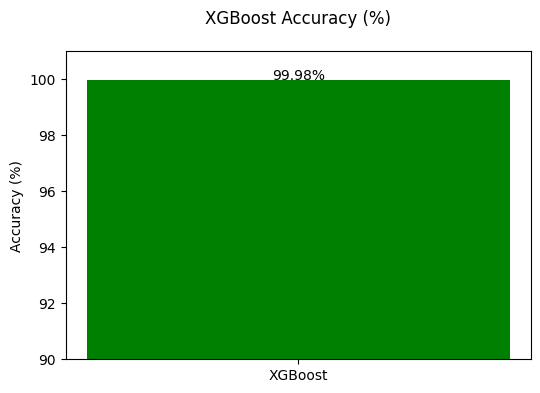

In [29]:


import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(["XGBoost"],[xgb_per],color="green")

plt.ylim(90,101)

plt.title("XGBoost Accuracy (%)",pad=20)

plt.ylabel("Accuracy (%)")

plt.text(0,xgb_per,str(xgb_per)+"%",ha="center")

plt.show()

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train,y_train)

gb_pred = gb.predict(X_test)

gb_acc = accuracy_score(y_test,gb_pred)

gb_per = round(gb_acc*100,2)

print("Gradient Boosting Accuracy:",gb_per,"%")

Gradient Boosting Accuracy: 99.95 %


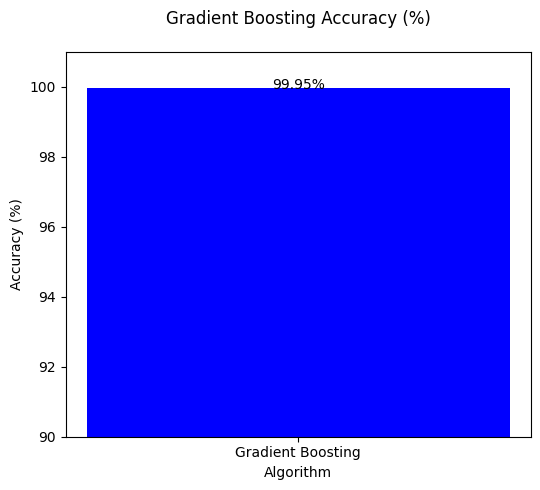

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(["Gradient Boosting"], [gb_per], color="blue")

plt.title("Gradient Boosting Accuracy (%)", pad=20)

plt.xlabel("Algorithm")

plt.ylabel("Accuracy (%)")

plt.ylim(90,101)

plt.text(0, gb_per, str(gb_per)+"%", ha="center")

plt.show()

In [33]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(n_estimators=50)

ab.fit(X_train, y_train)

ab_pred = ab.predict(X_test)

ab_acc = accuracy_score(y_test, ab_pred)

ab_per = round(ab_acc*100,2)

print("AdaBoost Accuracy:", ab_per,"%")

AdaBoost Accuracy: 99.92 %


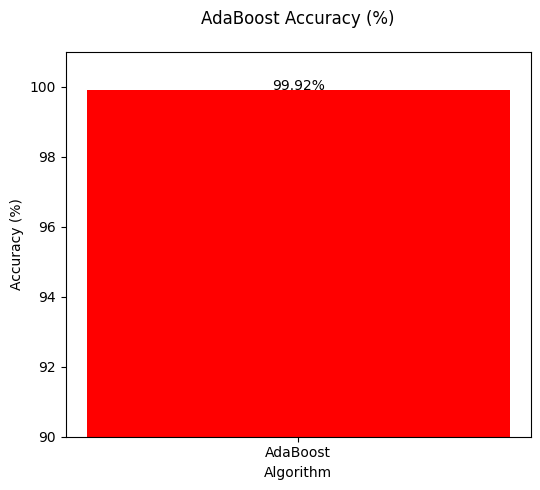

In [35]:
plt.figure(figsize=(6,5))

plt.bar(["AdaBoost"], [ab_per], color="red")

plt.title("AdaBoost Accuracy (%)", pad=20)

plt.xlabel("Algorithm")

plt.ylabel("Accuracy (%)")

plt.ylim(90,101)

plt.text(0, ab_per, str(ab_per)+"%", ha="center")

plt.show()

In [36]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

base_models = [
("xgb", XGBClassifier()),
("gb", GradientBoostingClassifier())
]

meta_model = LogisticRegression()

stack = StackingClassifier(
estimators = base_models,
final_estimator = meta_model
)

stack.fit(X_train, y_train)

stack_pred = stack.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)

stack_per = round(stack_acc*100,2)

print("Hybrid Model Accuracy:", stack_per,"%")

Hybrid Model Accuracy: 99.97 %


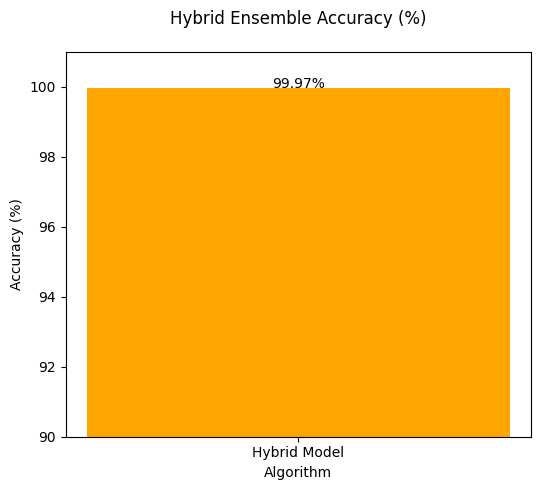

In [38]:
plt.figure(figsize=(6,5))

plt.bar(["Hybrid Model"], [stack_per], color="orange")

plt.title("Hybrid Ensemble Accuracy (%)", pad=20)

plt.xlabel("Algorithm")

plt.ylabel("Accuracy (%)")

plt.ylim(90,101)

plt.text(0, stack_per, str(stack_per)+"%", ha="center")

plt.show()

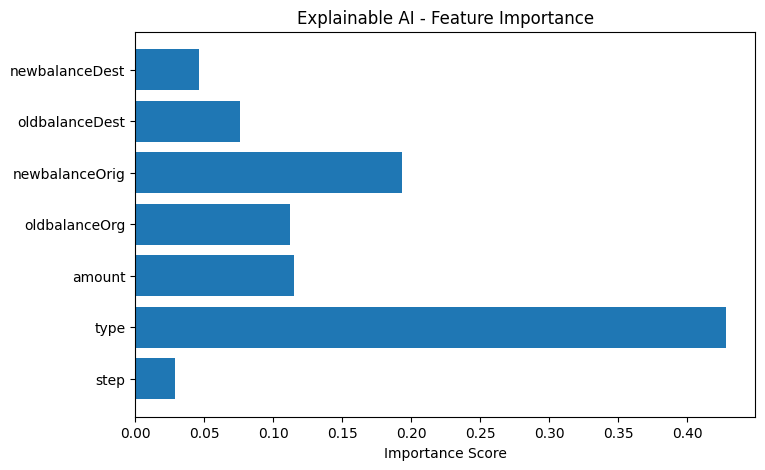

In [39]:
importances = xgb.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importances)

plt.title("Explainable AI - Feature Importance")

plt.xlabel("Importance Score")

plt.show()

In [40]:
!pip install lightgbm

In [41]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier()

lgb.fit(X_train,y_train)

lgb_pred = lgb.predict(X_test)

lgb_acc = accuracy_score(y_test,lgb_pred)

lgb_per = round(lgb_acc*100,2)

print("LightGBM Accuracy:",lgb_per,"%")

[LightGBM] [Info] Number of positive: 102, number of negative: 79898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005969 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1535
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001275 -> initscore=-6.663533
[LightGBM] [Info] Start training from score -6.663533
LightGBM Accuracy: 99.63 %


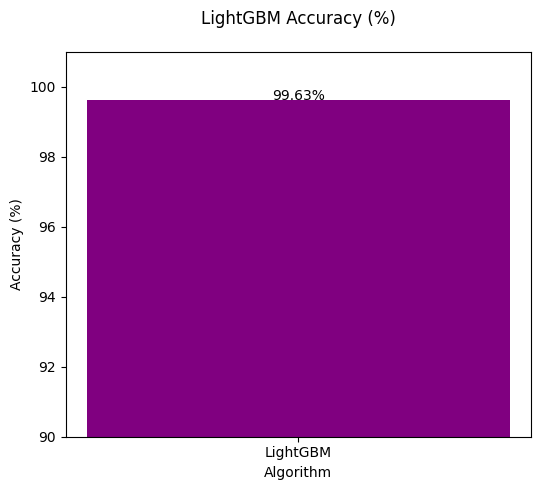

In [43]:
plt.figure(figsize=(6,5))

plt.bar(["LightGBM"],[lgb_per],color="purple")

plt.title("LightGBM Accuracy (%)",pad=20)

plt.xlabel("Algorithm")

plt.ylabel("Accuracy (%)")

plt.ylim(90,101)

plt.text(0,lgb_per,str(lgb_per)+"%",ha="center")

plt.show()

In [44]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(n_estimators=100)

et.fit(X_train,y_train)

et_pred = et.predict(X_test)

et_acc = accuracy_score(y_test,et_pred)

et_per = round(et_acc*100,2)

print("Extra Trees Accuracy:",et_per,"%")

Extra Trees Accuracy: 99.95 %


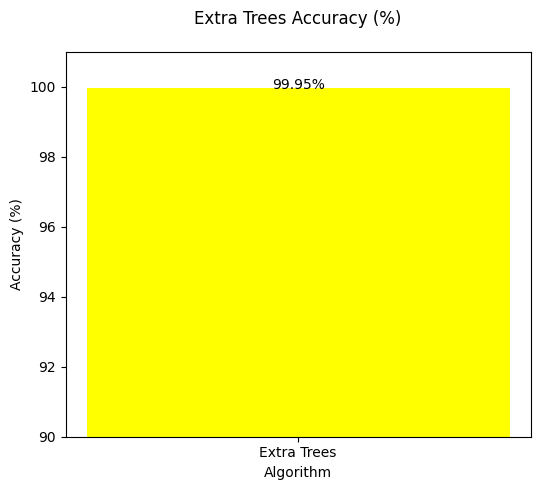

In [50]:
plt.figure(figsize=(6,5))

plt.bar(["Extra Trees"],[et_per],color="yellow")

plt.title("Extra Trees Accuracy (%)",pad=20)

plt.xlabel("Algorithm")

plt.ylabel("Accuracy (%)")

plt.ylim(90,101)

plt.text(0,et_per,str(et_per)+"%",ha="center")

plt.show()

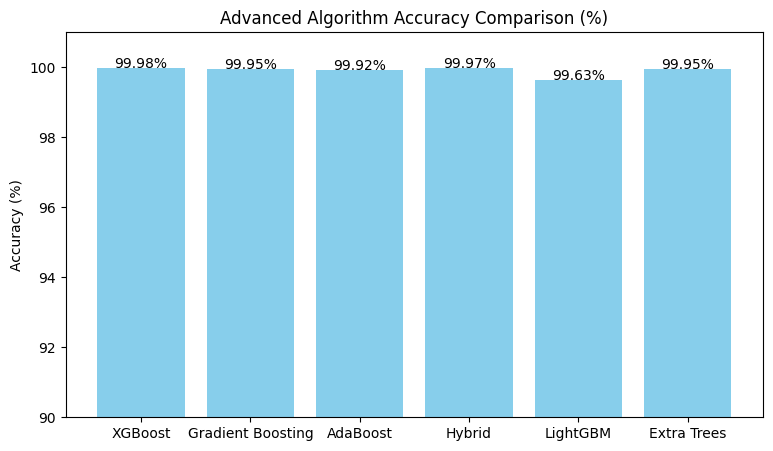

In [48]:
models = ["XGBoost","Gradient Boosting","AdaBoost","Hybrid","LightGBM","Extra Trees"]

accuracy = [xgb_per,gb_per,ab_per,stack_per,lgb_per,et_per]

plt.figure(figsize=(9,5))

plt.bar(models,accuracy,color="skyblue")

plt.ylim(90,101)

plt.title("Advanced Algorithm Accuracy Comparison (%)")

plt.ylabel("Accuracy (%)")

for i,v in enumerate(accuracy):
    plt.text(i,v,str(v)+"%",ha="center")

plt.show()

In [49]:
import pandas as pd

models = [
"XGBoost",
"Gradient Boosting",
"AdaBoost",
"Hybrid Ensemble",
"LightGBM",
"Extra Trees"
]

accuracy = [
xgb_per,
gb_per,
ab_per,
stack_per,
lgb_per,
et_per
]

results_table = pd.DataFrame({
"Algorithm": models,
"Prediction Accuracy (%)": accuracy
})

results_table

,Algorithm,Prediction Accuracy (%)
0,XGBoost,99.98
1,Gradient Boosting,99.95
2,AdaBoost,99.92
3,Hybrid Ensemble,99.97
4,LightGBM,99.63
5,Extra Trees,99.95
